In [128]:
import numpy as np
import matplotlib.pyplot as plt
import pywt
import pycwt as wavelet
import xarray as xr
import utils
from cmcrameri import cm

from matplotlib.ticker import ScalarFormatter

## Setup plot defaults
plt.rcParams['figure.figsize'] = [12, 4]
plt.rcParams.update({'font.size': 16})
plt.rcParams.update({
  "text.usetex": True,
  "font.family": "sans-serif",
  "font.sans-serif": ["Helvetica Light"],
})

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Evaluate spectral characteristics of potential signals

In [129]:
def calc_cwt(signal, wavelet_name):

  dt = 1
  if wavelet_name == 'morl':
    mother = wavelet.Morlet(6)
  else:
    raise ValueError('Other wavelets not implemented.')

  s0 = 2 * dt      # Starting scale, twice the sampling period
  dj = 1 / 12      # Twelve sub-octaves per octave
  J = 6 / dj

  coeffs, scales, freqs, coi, _, _ = wavelet.cwt(signal, dt, dj, s0, J, mother)

  # Convert frequencies to periods
  periods = 1 / freqs

  return coeffs, periods, coi

def calculate_coherence(signal1, signal2):
  dt = 1
  s0 = 2 * dt      # Starting scale, twice the sampling period
  dj = 1 / 12      # Twelve sub-octaves per octave
  J = 6 / dj
  mother = wavelet.Morlet(6)

  # Calculate the wavelet coherence
  # The wct function handles the cross-wavelet transform and smoothing
  rsq, phase, coi, freq, sig = wavelet.wct(
        signal1, signal2, dt, dj=dj, s0=s0, J=J, wavelet=mother, sig=False
    )

  # Convert frequencies to periods for easier interpretation
  periods = 1 / freq

  return rsq, phase, periods, coi

def plot_cwt(scenario, signal, t, coeffs, periods, coi, tas=True):
  fig, axs = plt.subplots(2, 1, figsize=(8, 6), gridspec_kw={'height_ratios': [1, 3]}, sharex='col', constrained_layout=True)
  fig.suptitle(f'{scenario}', fontsize=16)

  # Plot the original signal
  axs[0].plot(t, signal, color='black', alpha=0.8)
  if tas:
    axs[0].set_ylabel(r'$\overline{\Delta T}(t)$ [$^\circ$C]')
  else:
    axs[0].set_ylabel(r'ERF [Wm$^{-2}$]')
  axs[0].grid(True, linestyle=':', alpha=0.6)

  # Plot the CWT coefficients (Scalogram)
  vmax=abs(coeffs[np.where(periods < 64)[0],:]).max()
  #vmax=10
  im = axs[1].imshow(np.abs(coeffs), extent=[t[0], t[-1], periods[-1], periods[0]],
                     cmap=cm.devon_r, aspect='auto', vmax=vmax, vmin=abs(coeffs).min())

  axs[1].fill_between(t, coi, periods[-1], facecolor='black', alpha=0.1, label='Cone of Influence')

  axs[1].set_xlabel('Time (yr)')
  axs[1].set_ylabel('Period (yr)')
  axs[1].set_yscale('log')
  axs[1].set_ylim([periods[-1],periods[0]])

  y_ticks = [2, 4, 8, 16, 32, 64, 128]
  axs[1].set_yticks([tick for tick in y_ticks if periods[0] <= tick <= periods[-1]])
  axs[1].get_yaxis().set_major_formatter(ScalarFormatter())

  # Add a colorbar
  cbar = fig.colorbar(im, ax=axs[1])
  cbar.set_label('Magnitude')

  return

def plot_cwt_multi(scenarios, signals, t, coeffs, periods):
  n_scenarios = len(scenarios)
  fig, axes = plt.subplots(2, n_scenarios, figsize=(12, 6), gridspec_kw={'height_ratios': [1, 3]}, sharex='col', sharey='row', constrained_layout=True)

  vmax = 0
  vmin = np.inf
  for scenario in scenarios:
    scen_max, scen_min = abs(coeffs[scenario]).max(), abs(coeffs[scenario]).min()
    if scen_max > vmax: vmax = scen_max
    if scen_min < vmin: vmin = scen_min

  # Plot the original signal
  for i, ax in enumerate(axes.flat):
    if i < n_scenarios:
      scenario = scenarios[i]
      ax.set_title(f'{scenario}', fontsize=16)
      ax.plot(t[scenario], signals[scenario], color='black', alpha=0.8)
      ax.grid(True, linestyle=':', alpha=0.6)

      if i == 0:
        ax.set_ylabel('Variable')

    else:
      # Plot the CWT coefficients (Scalogram)
      scenario = scenarios[i % n_scenarios]
      im = ax.imshow(np.abs(coeffs[scenario]), extent=[t[scenario][0], t[scenario][-1],
                      periods[scenario][-1], periods[scenario][0]], cmap=cm.lipari, aspect='auto',
                      vmax=vmax, vmin=vmin)

      ax.set_xlabel('Time (yr)')
      ax.set_yscale('log')
      y_ticks = [2, 4, 8, 16, 32, 64, 128]
      ax.set_yticks(y_ticks)
      ax.get_yaxis().set_major_formatter(ScalarFormatter())

      if i == n_scenarios:
        ax.set_ylabel('Period (yr)')

  # Add a colorbar
  cbar = fig.colorbar(im, ax=axes[-1])
  cbar.set_label('Magnitude',size=14)

  return

In [189]:
def plot_coherence(scenario, tas, ERF, t, coeffs, periods, coi, abrupt=True, cmip=True, example=None):
  fig, axs = plt.subplots(2, 1, figsize=(8, 6), gridspec_kw={'height_ratios': [1, 3]}, sharex='col', constrained_layout=True)
  fig.suptitle(f'{scenario}', fontsize=16, x=0.45)

  # Plot the original signal
  axs[0].plot(t, tas, color=cm.batlowS(0), alpha=0.8)
  axs[0].set_ylabel(r'$\overline{\Delta T}(t)$ [$^\circ$C]',color=cm.batlowS(0))

  axtwin = axs[0].twinx()
  axtwin.plot(t, ERF, color=cm.batlowS(2), alpha=0.8)

  axtwin.set_ylabel(r'ERF [Wm$^{-2}$]', color=cm.batlowS(2))
  axs[0].grid(True, linestyle=':', alpha=0.6)

  # Plot the CWT coefficients (Scalogram)
  vmax=abs(coeffs[np.where(periods < 64)[0],:]).max()
  #vmax=10
  im = axs[1].imshow(np.abs(coeffs), extent=[t[0], t[-1], periods[-1], periods[0]],
                     cmap=cm.devon_r, aspect='auto', vmax=vmax, vmin=abs(coeffs).min())

  axs[1].fill_between(t, coi, periods[-1], hatch='/', lw=3, ls='--',edgecolor='white', alpha=0.2, label='Cone of Influence')

  axs[1].set_xlabel('Time (yr)')
  axs[1].set_ylabel('Period (yr)')
  axs[1].set_yscale('log')
  axs[1].set_ylim([periods[0],periods[-1]])

  y_ticks = [2, 4, 8, 16, 32, 64, 128]
  axs[1].set_yticks([tick for tick in y_ticks if periods[0] <= tick <= periods[-1]])
  axs[1].get_yaxis().set_major_formatter(ScalarFormatter())
  axs[1].legend(loc = 'lower left')

  if example == 1:
    axs[0].set_ylim([-2.5,2.5])
    axtwin.set_ylim([-2.5,2.5])

  else:
    if abrupt:
      if cmip:
        axs[0].set_ylim([-1,7])
        axtwin.set_ylim([-1,9])

        axs[0].set_xlim([300,550])
        axs[0].set_xticks([300, 350, 400, 450, 500, 550],[1750, 1800, 1850, 1900, 1950, 2000])
      else:
        axs[0].set_ylim([-1,7])
        axtwin.set_ylim([-1,9])

        axs[0].set_xlim([250,500])
        axs[0].set_xticks([200, 250, 300, 350, 400, 450, 500],[1700, 1750, 1800, 1850, 1900, 1950, 2000])
    else:
      if cmip:
        axs[0].set_ylim([-1,7])
        axtwin.set_ylim([-1,9])

        axs[0].set_xlim([400,650])
        axs[0].set_xticks([400, 450, 500, 550, 600, 650],[1850, 1900, 1950, 2000, 2050, 2100])
      else:
        axs[0].set_ylim([-1,7])
        axtwin.set_ylim([-1,9])

        #axs[0].set_xlim([300,650])
        axs[0].set_xticks([0, 50, 100, 150, 200, 250],[1850, 1900, 1950, 2000, 2050, 2100])

  # Add a colorbar
  cbar = fig.colorbar(im, ax=axs[1])
  cbar.set_label('Signal Coherence')

  return

#### Abrupt 4xCO2

In [131]:
# Load data
scenario_abrupt = 'abrupt-4xCO2'
ERF_abrupt_ds_path = f'data/MPI/{scenario_abrupt}/{scenario_abrupt}_ERF_global_anomaly.nc4'
tas_abrupt_ds_path = f'data/MPI/{scenario_abrupt}/{scenario_abrupt}_tas_global_anomaly.nc4'
ERF_abrupt_ds = xr.open_dataset(ERF_abrupt_ds_path)
tas_abrupt_ds = xr.open_dataset(tas_abrupt_ds_path)

scenario_piControl = 'piControl'
ERF_piControl_ds_path = f'data/MPI/{scenario_piControl}/{scenario_piControl}_ERF_global_anomaly.nc4'
tas_piControl_ds_path = f'data/MPI/{scenario_piControl}/{scenario_piControl}_tas_global_anomaly.nc4'
ERF_piControl_ds = xr.open_dataset(ERF_piControl_ds_path)
tas_piControl_ds = xr.open_dataset(tas_piControl_ds_path)
tas_piControl_ds = tas_piControl_ds['__xarray_dataarray_variable__'].to_dataset(name = 'tas')

ERF_abrupt_np = np.concatenate([ERF_piControl_ds.ERF.values - np.mean(ERF_piControl_ds.ERF.values), ERF_abrupt_ds.ERF.values])
tas_abrupt_np = np.concatenate([tas_piControl_ds.tas.values - np.mean(tas_piControl_ds.tas.values), tas_abrupt_ds.tas.values])
t_abrupt = np.arange(len(ERF_abrupt_np))

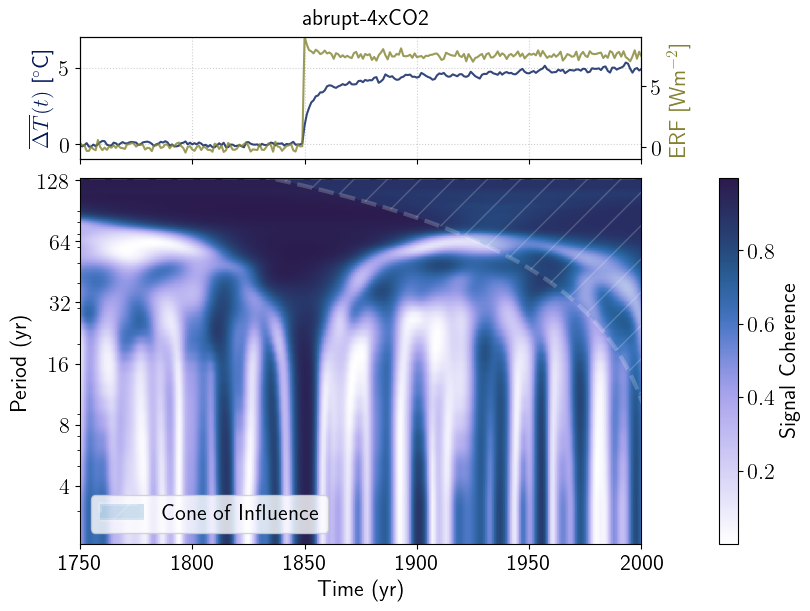

In [167]:
# Define wavelet transform parameters
wavelet_name = 'morl'

min_period = 2
max_period = 128
total_scales = 500

# Perform the CWT
coeffs_abrupt_ERF, periods_abrupt_ERF, coi_abrupt_ERF = calc_cwt(ERF_abrupt_np, wavelet_name)
coeffs_abrupt_tas, periods_abrupt_tas, coi_abrupt_tas = calc_cwt(tas_abrupt_np, wavelet_name)
coi_abrupt_ERF = np.array([c if c >= 2 else 2 for c in coi_abrupt_ERF])
coi_abrupt_tas = np.array([c if c >= 2 else 2 for c in coi_abrupt_tas])
rsq_abrupt, phase, periods, coi_coher = calculate_coherence(ERF_abrupt_np, tas_abrupt_np)
#plot_cwt(scenario_abrupt, ERF_abrupt_np, t_abrupt, coeffs_abrupt_ERF, periods_abrupt_ERF, coi_abrupt_ERF, tas=False)
#plot_cwt(scenario_abrupt, tas_abrupt_np, t_abrupt, coeffs_abrupt_tas, periods_abrupt_tas, coi_abrupt_tas)
plot_coherence(scenario_abrupt, tas_abrupt_np, ERF_abrupt_np, t_abrupt, rsq_abrupt, periods, coi_coher)
plt.savefig('Committee_Meeting_Figs/coherence_abrupt.pdf')

#### SSP585

In [192]:
scenario_ssp585 = 'ssp585'
ERF_ssp585_ds_path = 'data/MPI/combined_historical_ssp585_ERF_global_anomaly.nc'
ERF_ssp585_ds = xr.open_dataset(ERF_ssp585_ds_path)
ERF_ssp585_np = ERF_ssp585_ds.ERF.values

tas_ssp585_ds_path = 'data/MPI/combined_historical_ssp585_tas_global_anomaly.nc'
tas_ssp585_ds = xr.open_dataset(tas_ssp585_ds_path)
tas_ssp585_np = tas_ssp585_ds.tas.values

ERF_ssp585_np = np.concatenate([ERF_piControl_ds.ERF.values - np.mean(ERF_piControl_ds.ERF.values), ERF_ssp585_np])
tas_ssp585_np = np.concatenate([tas_piControl_ds.tas.values - np.mean(tas_piControl_ds.tas.values), tas_ssp585_np])
t_ssp585 = np.arange(len(ERF_ssp585_np))

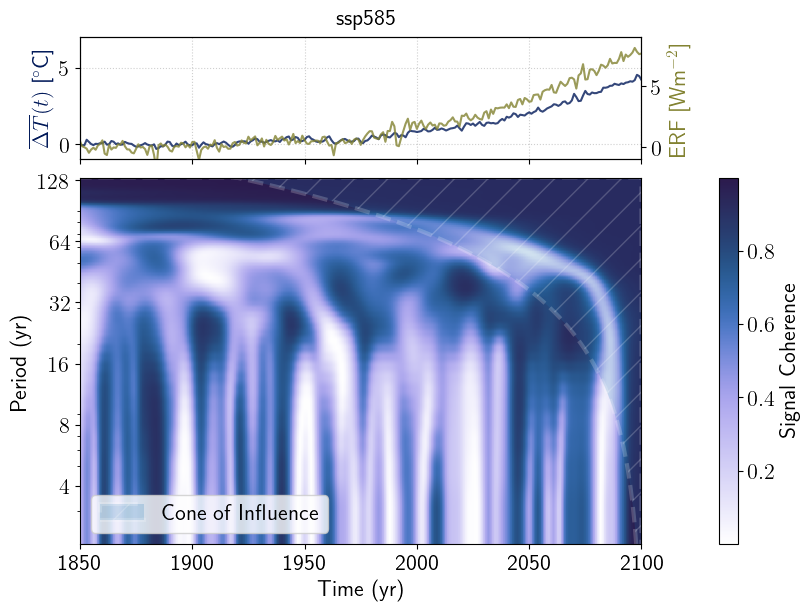

In [194]:
# Define wavelet transform parameters
wavelet_name = 'morl'

min_period = 2
max_period = 128
total_scales = 200

# Perform the CWT
coeffs_ssp585_ERF, periods_ssp585_ERF, coi_ssp585_ERF = calc_cwt(ERF_ssp585_np, wavelet_name)
coeffs_ssp585_tas, periods_ssp585_tas, coi_ssp585_tas = calc_cwt(tas_ssp585_np, wavelet_name)
coi_ssp585_ERF = np.array([c if c >= 2 else 2 for c in coi_ssp585_ERF])
coi_ssp585_tas = np.array([c if c >= 2 else 2 for c in coi_ssp585_tas])
rsq_ssp585, phase, periods, coi_coher = calculate_coherence(ERF_ssp585_np, tas_ssp585_np)
#plot_cwt(scenario_ssp585, ERF_ssp585_np, t_ssp585, coeffs_ssp585_ERF, periods_ssp585_ERF, coi_ssp585_ERF, tas=False)
#plot_cwt(scenario_ssp585, tas_ssp585_np, t_ssp585, coeffs_ssp585_tas, periods_ssp585_tas, coi_ssp585_tas)
plot_coherence(scenario_ssp585, tas_ssp585_np, ERF_ssp585_np, t_ssp585, rsq_ssp585, periods, coi_coher, abrupt=False)
plt.savefig('Committee_Meeting_Figs/coherence_ssp585.pdf')

In [88]:
class three_box_ebm:
  def __init__(self, lam, C, D, T0, dt):
    self.C    = C                     # Heat capacity [J kg-1 K-1]
    self.D    = D                     # Diffusivity [W m-2 K-1]
    self.dt   = dt                    # Time step [seconds]
    self.lam  = self.make_lam(lam, D) # Feedback parameter [W m-2 K-1]
    self.T0   = T0                    # Initial temperature [K]

  def make_lam(self, lam_diag, D=0.0):
    lam = np.asarray(lam_diag, dtype=float)
    lam = np.diag(lam)

    if D != 0.0:
      lam += np.diag([D, 2*D, D])
      lam[0, 1] = lam[1, 0] = -D
      lam[1, 2] = lam[2, 1] = -D

    return lam

  def box_iter(self, F, Nt_year):
    Nt_sec = int(Nt_year * 3600 * 24 * 365.24 / self.dt)
    T_out, T_integrate = np.empty((3, Nt_year + 1)), np.empty((3, Nt_sec))

    T_out[:, 0], T_integrate[:, 0] = self.T0, self.T0
    B = np.eye(len(self.C))

    i_save = 1
    for n in range(1, Nt_sec):
      try:
        Ft = F(n - 1)
      except:
        Ft = F[:,n - 1]

      RHS = 1 / self.C * (-self.lam @ T_integrate[:, n - 1] + B @ Ft)
      T_integrate[:, n] = T_integrate[:, n - 1] + self.dt * RHS

      if n % 365 == 0:
        T_out[:, i_save] = T_integrate[:, n]
        i_save += 1

    return T_out

  def plot_box(self, T_out):
    plt.plot(T_out.T)
    return

# Required constants
rho_w = 1e3                         # Water density [kg m-3]
cp_w = 4e3                          # Water specific heat capacity [J kg-1 K-1]
h = np.array([1500, 5, 150])       # Water slab thickness [m]
C = h * rho_w * cp_w                # Effective heat capacity [J m-2 K-1]
D = 0.55
lam_diag = np.array([0.67, 0.86, 2.0]) # Feedback parameters [W m-2 K-1]
T0 = np.zeros(3)
dt = 3600 * 24

Nt_year = 250

box_test = three_box_ebm(lam_diag, C, D, T0, dt)
F_abr = lambda t: np.zeros(3) if t < 91310 else 7.4 * np.ones(3)
F_abr_3box = np.concatenate([np.zeros((Nt_year, 3)), np.array([7.4*np.ones(3) for t in range(Nt_year + 1)])])
T_abr_3box = box_test.box_iter(F_abr, 2*Nt_year)

In [99]:
# Define constants for the exponential forcing
t_star_years, RF_end, t_final_years = 50, 8.5, 250

# Calculate the total number of time steps for the simulation
Nt_sec = int(Nt_year * 365.24 * 24 * 3600 / dt)

# Create a time vector in units of years, but with Nt_sec steps
t_years = np.arange(Nt_sec) * dt / (365.24 * 24 * 3600)

# Calculate the forcing array
amp = RF_end / np.exp(t_final_years / t_star_years)
F_exp_3box = np.tile(amp * np.exp(t_years / t_star_years), (3, 1))
T_exp_3box = box_test.box_iter(F_exp_3box, Nt_year)

In [114]:
# Define constants for the exponential forcing
t_star_years, RF_end, t_final_years = 50, 8.5, 250

# Calculate the total number of time steps for the simulation
Nt_sec = int(Nt_year * 365.24 * 24 * 3600 / dt)

# Create a time vector in units of years, but with Nt_sec steps
t_years_plot = np.arange(Nt_year+1)

# Calculate the forcing array
amp = RF_end / np.exp(t_final_years / t_star_years)
F_exp_plot = np.tile(amp * np.exp(t_years_plot / t_star_years), (3, 1))

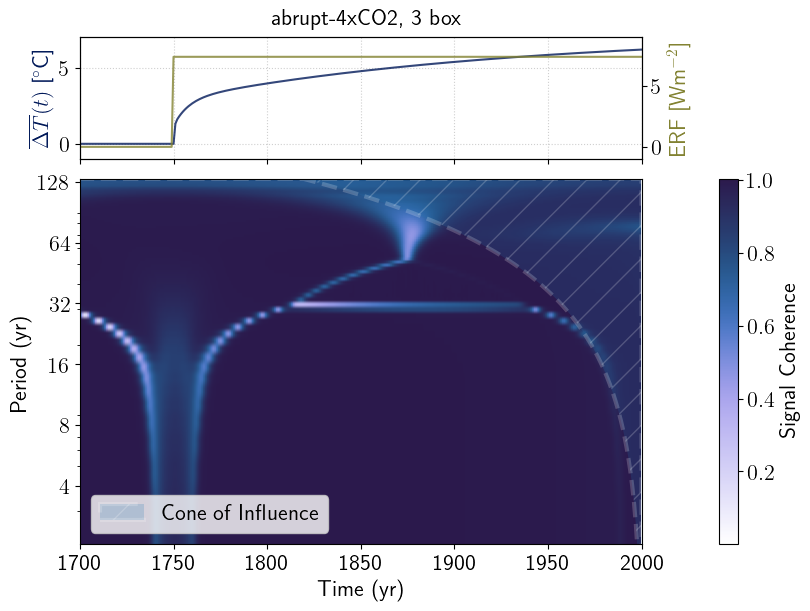

In [165]:
t_abrupt3 = np.arange(0,2*Nt_year + 1)
scenario_abrupt3 = 'abrupt-4xCO2, 3 box'

# Define wavelet transform parameters
wavelet_name = 'morl'

min_period = 2
max_period = 128
total_scales = 500

ind = 0

# Perform the CWT
coeffs_abrupt3_F, periods_abrupt3_F, coi_abrupt3_F = calc_cwt(F_abr_3box[:,ind], wavelet_name)
coeffs_abrupt3_tas, periods_abrupt3_tas, coi_abrupt3_tas = calc_cwt(np.mean(T_abr_3box, axis=0), wavelet_name)
coi_abrupt3_F = np.array([c if c >= 2 else 2 for c in coi_abrupt3_F])
coi_abrupt3_tas = np.array([c if c >= 2 else 2 for c in coi_abrupt3_tas])
rsq_abrupt3, phase, periods, coi_coher = calculate_coherence(F_abr_3box[:,ind], np.mean(T_abr_3box, axis=0))
#plot_cwt(scenario_abrupt3, F_abr_3box[:,ind], t_abrupt3, coeffs_abrupt3_F, periods_abrupt_ERF, coi_abrupt3_F, tas=False)
#plot_cwt(scenario_abrupt3, np.mean(T_abr_3box, axis=0), t_abrupt3, coeffs_abrupt3_tas, periods_abrupt_tas, coi_abrupt3_tas)
plot_coherence(scenario_abrupt3, np.mean(T_abr_3box, axis=0), F_abr_3box[:,ind], t_abrupt3, rsq_abrupt3, periods, coi_coher, cmip=False)
plt.savefig('Committee_Meeting_Figs/coherence_abrupt3.pdf')

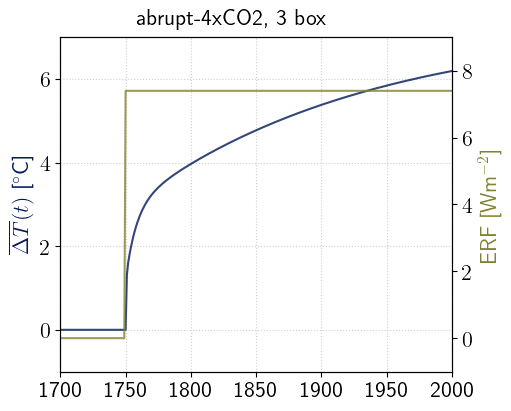

In [96]:
fig, axs = plt.subplots(figsize=(5, 4), constrained_layout=True)
fig.suptitle(f'{scenario_abrupt3}', fontsize=16, x=0.45)

# Plot the original signal
axs.plot(np.mean(T_abr_3box, axis=0), color=cm.batlowS(0), alpha=0.8)
axs.set_ylabel(r'$\overline{\Delta T}(t)$ [$^\circ$C]',color=cm.batlowS(0))

axtwin = axs.twinx()
axtwin.plot( F_abr_3box[:,ind], color=cm.batlowS(2), alpha=0.8)

axtwin.set_ylabel(r'ERF [Wm$^{-2}$]', color=cm.batlowS(2))
axs.grid(True, linestyle=':', alpha=0.6)

axs.set_ylim([-1,7])
axtwin.set_ylim([-1,9])

axs.set_xlim([250,500])
axs.set_xticks([200, 250, 300, 350, 400, 450, 500],[1700, 1750, 1800, 1850, 1900, 1950, 2000])

plt.savefig('Committee_Meeting_Figs/timeseries_abrupt3.pdf')

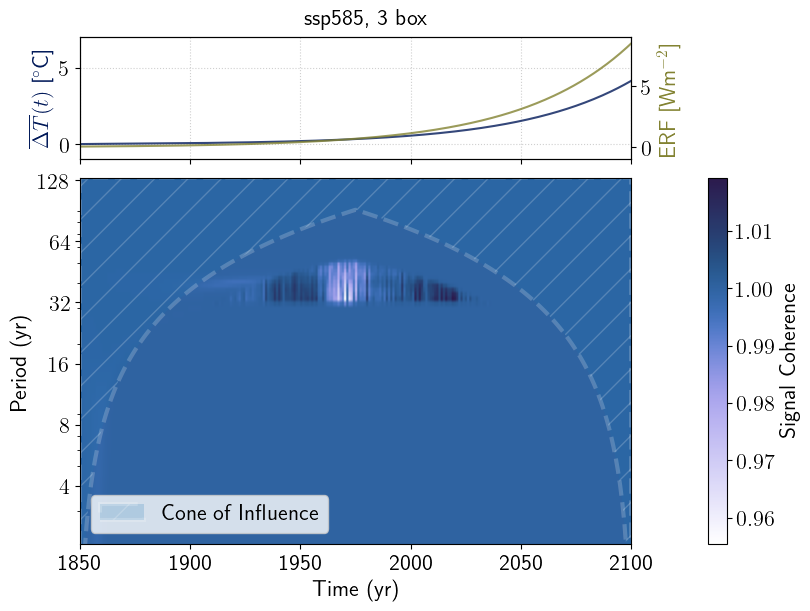

In [164]:
t_ssp3 = np.arange(0,Nt_year + 1)
scenario_ssp3 = 'ssp585, 3 box'

# Define wavelet transform parameters
wavelet_name = 'morl'

min_period = 2
max_period = 128
total_scales = 500

ind = 0

# Perform the CWT
#coeffs_abrupt3_F, periods_abrupt3_F, coi_abrupt3_F = calc_cwt(F_abr_3box[:,ind], wavelet_name)
#coeffs_abrupt3_tas, periods_abrupt3_tas, coi_abrupt3_tas = calc_cwt(np.mean(T_abr_3box, axis=0), wavelet_name)
#coi_abrupt3_F = np.array([c if c >= 2 else 2 for c in coi_abrupt3_F])
#coi_abrupt3_tas = np.array([c if c >= 2 else 2 for c in coi_abrupt3_tas])
rsq_abrupt3, phase, periods, coi_coher = calculate_coherence(F_exp_plot[ind,:], np.mean(T_exp_3box, axis=0))
#plot_cwt(scenario_abrupt3, F_abr_3box[:,ind], t_abrupt3, coeffs_abrupt3_F, periods_abrupt_ERF, coi_abrupt3_F, tas=False)
#plot_cwt(scenario_abrupt3, np.mean(T_abr_3box, axis=0), t_abrupt3, coeffs_abrupt3_tas, periods_abrupt_tas, coi_abrupt3_tas)
plot_coherence(scenario_ssp3, np.mean(T_exp_3box, axis=0), F_exp_plot[ind,:], t_ssp3, rsq_abrupt3, periods, coi_coher, abrupt=False, cmip=False)
plt.savefig('Committee_Meeting_Figs/coherence_ssp3.pdf')

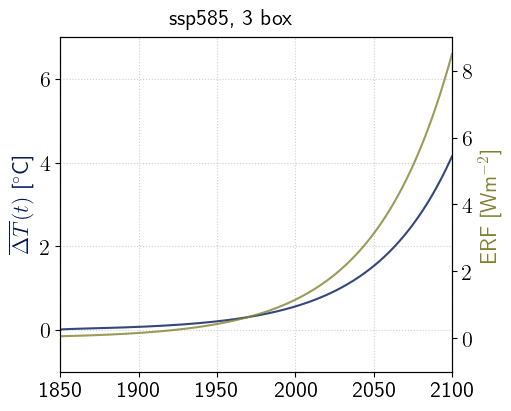

In [127]:
fig, axs = plt.subplots(figsize=(5, 4), constrained_layout=True)
fig.suptitle(f'{scenario_ssp3}', fontsize=16, x=0.45)

# Plot the original signal
axs.plot(np.mean(T_exp_3box, axis=0), color=cm.batlowS(0), alpha=0.8)
axs.set_ylabel(r'$\overline{\Delta T}(t)$ [$^\circ$C]',color=cm.batlowS(0))

axtwin = axs.twinx()
axtwin.plot( F_exp_plot[ind,], color=cm.batlowS(2), alpha=0.8)

axtwin.set_ylabel(r'ERF [Wm$^{-2}$]', color=cm.batlowS(2))
axs.grid(True, linestyle=':', alpha=0.6)

axs.set_ylim([-1,7])
axtwin.set_ylim([-1,9])

axs.set_xlim([0,250])
axs.set_xticks([0, 50, 100, 150, 200, 250],[1850, 1900, 1950, 2000, 2050, 2100])

plt.savefig('Committee_Meeting_Figs/timeseries_ssp3.pdf')

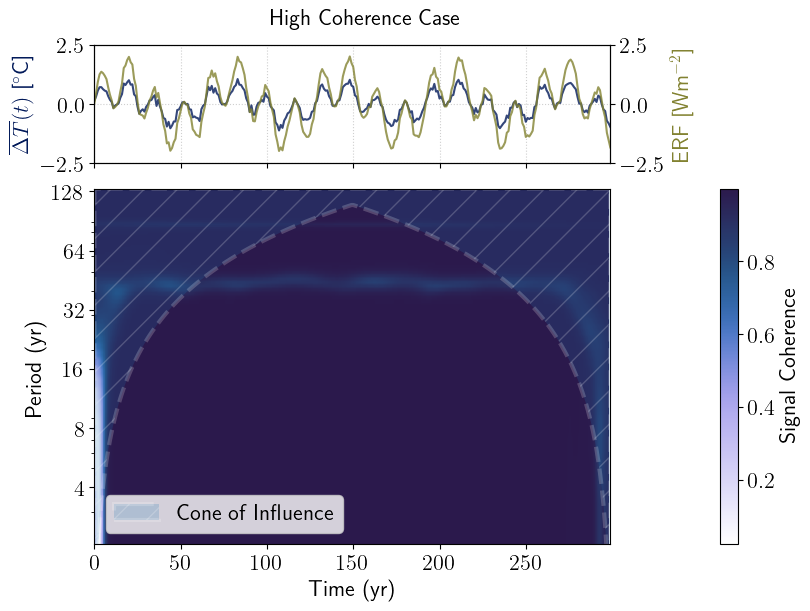

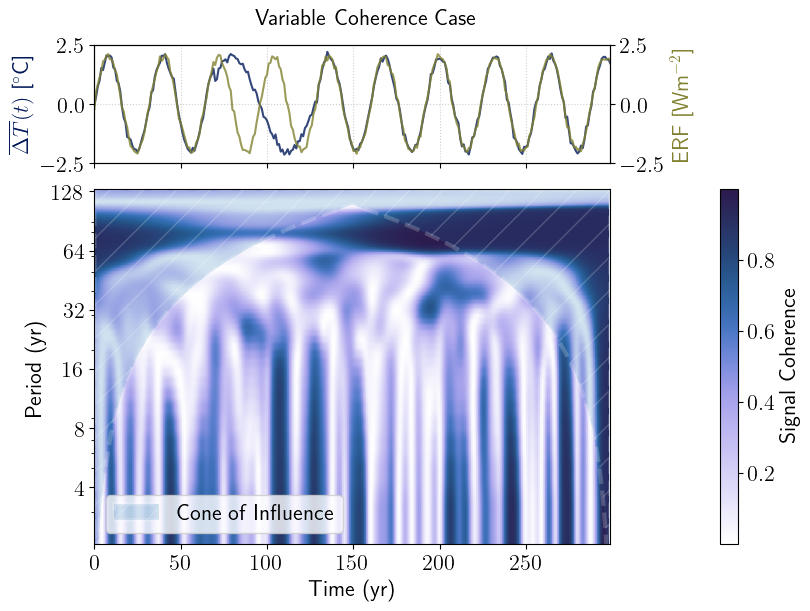

In [190]:
import numpy as np
import matplotlib.pyplot as plt

# --- Basic Parameters ---
# Let's assume the time series represents 200 years of data
t = np.arange(300)

# --- Signal Pair 1: High Coherence ---
# These two signals will share the same underlying frequency components
# throughout the entire time series.

# Create a base signal with a dominant 16-year cycle and some noise
base_signal = np.sin(2 * np.pi * t / 16) + np.sin(2 * np.pi * t / 64)
noise1 = np.random.normal(0, 0.1, len(t))
noise2 = np.random.normal(0, 0.1, len(t))

# ERF_coherent is the base signal plus some noise
ERF_coherent = base_signal + noise1

# tas_coherent is a scaled and slightly phase-shifted version of the base signal,
# plus its own noise. Because it's linearly related to the base signal,
# their coherence will be very high.
tas_coherent = 0.5 * (np.sin(2 * np.pi * t / 16 + np.pi/32) + np.sin(2 * np.pi * t / 64 + np.pi/32)) + noise1


# --- Signal Pair 2: Variable Coherence (with Decoherent Segment) ---
# This pair will be coherent, then decoherent, then coherent again. This is useful
# for identifying a change in the system's behavior.

# ERF_decoherent has a consistent 16-year cycle throughout.
ERF_decoherent = 2*np.sin(2 * np.pi * t / 32) + np.random.normal(0, 0.1, len(t))

# tas_decoherent starts with the same 16-year cycle, then abruptly switches
# to a 32-year cycle in the middle, and then switches back.

# Create an empty array for the tas_decoherent signal
tas_decoherent = np.zeros_like(t, dtype=float)

# Part 1 (Years 0-69): Coherent with a 16-year cycle
tas_decoherent[:70] = 2*np.sin(2 * np.pi * t[:70] / 32)

# Part 2 (Years 70-130): Decoherent with a 32-year cycle
tas_decoherent[70:130] = 2*np.sin(2 * np.pi * t[70:130] / 64)

# Part 3 (Years 130-200): Coherent again with a 16-year cycle
tas_decoherent[130:] = 2*np.sin(2 * np.pi * t[130:] / 32)

# Add some noise to the entire signal to make it more realistic
tas_decoherent += np.random.normal(0, 0.1, len(t))


# --- Example Usage (Optional Visualization) ---
# You can use this block to quickly visualize the generated signals

def plot_signals(t, erf_signal, tas_signal, title):
    """A simple function to plot the signal pairs."""
    fig, ax = plt.subplots(figsize=(10, 3))
    ax.plot(t, erf_signal, label='ERF Signal', color='C0')
    ax.plot(t, tas_signal, label='TAS Signal', color='C1', linestyle='--')
    ax.set_title(title)
    ax.set_xlabel('Time (years)')
    ax.set_ylabel('Amplitude')
    ax.grid(True, alpha=0.3)
    ax.legend()
    plt.show()

# To use, uncomment the lines below:
# print("Visualizing the highly coherent signals...")
#plot_signals(t, ERF_coherent, tas_coherent, 'Signal Pair 1: High Coherence')

# print("\nVisualizing the variably coherent signals...")
#plot_signals(t, ERF_decoherent, tas_decoherent, 'Signal Pair 2: Variable Coherence')


# --- How to use with your code ---
# Now you can pass these numpy arrays to your existing functions.
# For example:

# Coherent case:
rsq_coherent, phase_c, periods_c, coi_c = calculate_coherence(ERF_coherent, tas_coherent)
plot_coherence('High Coherence Case', tas_coherent, ERF_coherent, t, rsq_coherent, periods_c, coi_c, example=1)
plt.savefig('Committee_Meeting_Figs/high_coherence.pdf')

# Decoherent case:
rsq_decoherent, phase_d, periods_d, coi_d = calculate_coherence(ERF_decoherent, tas_decoherent)
plot_coherence('Variable Coherence Case', tas_decoherent, ERF_decoherent, t, rsq_decoherent, periods_d, coi_d, example=1)
plt.savefig('Committee_Meeting_Figs/low_coherence.pdf')

